In [1]:
import torch
from torchvision import datasets, transforms

def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    return device



def get_mnist(batch_size, train):
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.MNIST("data", 
                            train= train,
                            download=True,
                            transform = transform)
    dataset_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    return dataset_loader


In [2]:
train_dataset = get_mnist(batch_size=64, train=True)

In [3]:
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self, hidden_channels, latent_dim, kernel_size, stride, padding):
        super().__init__()
        self.kwargs = {
            "hidden_channels": hidden_channels,
            "latent_dim": latent_dim,
            "kernel_size": kernel_size,
            "stride": stride,
            "padding": padding,
        }
        self.conv_encoder = nn.Sequential(
            nn.Conv2d(1, hidden_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            after_conv1 = self.conv_encoder[:2](dummy)
            after_conv2 = self.conv_encoder(dummy)
            h1 = after_conv1.shape[2]
            h2 = after_conv2.shape[2]
            self.conv_out_shape = after_conv2.shape[1:]
            self.flat_size = after_conv2.flatten(1).shape[1]

        # output_padding resolves the ambiguity in ConvTranspose2d:
        # target = (input - 1) * stride - 2 * padding + kernel_size + output_padding
        self.op1 = h1 - ((h2 - 1) * stride - 2 * padding + kernel_size)
        self.op2 = 28 - ((h1 - 1) * stride - 2 * padding + kernel_size)

        self.encoder = nn.Sequential(
            self.conv_encoder,
            nn.Flatten(),
            nn.Linear(self.flat_size, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, self.flat_size),
            nn.ReLU(),
            nn.Unflatten(1, self.conv_out_shape),
            nn.ConvTranspose2d(hidden_channels, hidden_channels, kernel_size=kernel_size, stride=stride, padding=padding, output_padding=self.op1),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels, 1, kernel_size=kernel_size, stride=stride, padding=padding, output_padding=self.op2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


class ConvAutoencoderClassifier(ConvAutoencoder):
    def __init__(self, hidden_channels, latent_dim, kernel_size, stride, padding):
        super().__init__(hidden_channels, latent_dim, kernel_size, stride, padding)
        self.classifier = nn.Linear(latent_dim, 10)

    def forward(self, x):
        z = self.encoder(x)
        return self.classifier(z)


class ConvAutoencoderClassifierTrained(nn.Module):
    """Frozen pretrained autoencoder with a newly trained classifier head."""
    def __init__(self, trained_model: ConvAutoencoder):
        super().__init__()
        self.trained_model = trained_model
        self.kwargs = trained_model.kwargs
        self.classifier = nn.Linear(trained_model.kwargs["latent_dim"], 10)

    def forward(self, x):
        with torch.no_grad():
            z = self.trained_model.encoder(x)
        return self.classifier(z)


class ConvAutoencoderDecoderTrained(nn.Module):
    """Frozen pretrained encoder+classifier with a newly trained decoder head."""
    def __init__(self, trained_model: ConvAutoencoderClassifier):
        super().__init__()
        self.trained_model = trained_model
        self.kwargs = trained_model.kwargs
        self.decoder = nn.Sequential(
            nn.Linear(10, trained_model.flat_size),
            nn.ReLU(),
            nn.Unflatten(1, trained_model.conv_out_shape),
            nn.ConvTranspose2d(trained_model.kwargs["hidden_channels"], trained_model.kwargs["hidden_channels"], kernel_size=trained_model.kwargs["kernel_size"], stride=trained_model.kwargs["stride"], padding=trained_model.kwargs["padding"], output_padding=trained_model.op1),
            nn.ReLU(),
            nn.ConvTranspose2d(trained_model.kwargs["hidden_channels"], 1, kernel_size=trained_model.kwargs["kernel_size"], stride=trained_model.kwargs["stride"], padding=trained_model.kwargs["padding"], output_padding=trained_model.op2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        with torch.no_grad():
            z = self.trained_model.forward(x)
        return self.decoder(z)


## Q1 — Convolutional Autoencoder

### Network Architecture

The autoencoder consists of two symmetric paths that share no parameters.

**Encoder**
1. `Conv2d(1 → C, kernel=3, stride=1, padding=1)` + ReLU
2. `Conv2d(C → C, kernel=3, stride=1, padding=1)` + ReLU
3. `Flatten` → `Linear(C·28·28, d)`

**Decoder** (mirror)
1. `Linear(d, C·28·28)` + ReLU
2. `Unflatten` → `ConvTranspose2d(C → C, ...)` + ReLU
3. `ConvTranspose2d(C → 1, ...)` + **Sigmoid**

#### Design choices

| Choice | Rationale |
|---|---|
| stride=1, padding=1 | Preserves 28×28 spatial dims through all conv layers — no pooling or strided downsampling needed |
| 2 conv layers | Sufficient depth for MNIST's simple patterns; deeper stacks add little for 28×28 greyscale |
| ReLU hidden layers | Cheap, avoids vanishing gradients; no saturation in hidden activations |
| Sigmoid output | Maps decoder output to [0,1], matching normalized MNIST pixel values |
| Mean L1 loss | More robust to outlier pixels than L2; empirically produces sharper reconstructions |

#### How any latent dim `d` is supported

Because stride=1 and padding=1 keep the spatial size constant, the flattened feature size after both conv layers is always **C × 28 × 28**, regardless of `d`.  
The projection to and from the bottleneck is handled entirely by two Linear layers (`C·28·28 → d` and `d → C·28·28`), so `d` can be any positive integer without touching the convolutional architecture.


In [4]:
from itertools import product

CHANNELS = [3, 15]
LATENT_DIMS = [4, 16, 32]
KS, ST, PAD = 3, 1, 1

def make_configs():
    return list(product(CHANNELS, LATENT_DIMS))

autoencoder_models = [
    ConvAutoencoder(c, ld, KS, ST, PAD) for c, ld in make_configs()
]
encoder_classifier_models = [
    ConvAutoencoderClassifier(c, ld, KS, ST, PAD) for c, ld in make_configs()
]
# Types 3 and 4 are instantiated after training types 1 and 2

print(f"Autoencoder models: {len(autoencoder_models)}")
print(f"Encoder+Classifier models: {len(encoder_classifier_models)}")


Autoencoder models: 6
Encoder+Classifier models: 6


In [5]:
import numpy as np

def train_reconstruction(model, loader, num_epochs=10, lr=1e-3):
    device = get_device()
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    model.losses = []
    print(f"Training reconstruction  config={model.kwargs}")
    for epoch in range(num_epochs):
        model.train()
        batch_losses = []
        for images, _ in loader:
            images = images.to(device)
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        median_loss = np.median(batch_losses)
        model.losses.append(median_loss)
        print(f"  Epoch [{epoch+1}/{num_epochs}]  L1={median_loss:.4f}")
    return model


def train_classification(model, loader, num_epochs=10, lr=1e-3):
    device = get_device()
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.losses = []
    print(f"Training classifier  config={model.kwargs}")
    for epoch in range(num_epochs):
        model.train()
        batch_losses = []
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        median_loss = np.median(batch_losses)
        model.losses.append(median_loss)
        print(f"  Epoch [{epoch+1}/{num_epochs}]  CE={median_loss:.4f}")
    return model


def get_balanced_subset(n_per_class=10, batch_size=64):
    from torch.utils.data import TensorDataset, DataLoader
    full = datasets.MNIST("data", train=True, download=True,
                          transform=transforms.Compose([transforms.ToTensor()]))
    found_images, found_labels = {d: [] for d in range(10)}, {d: [] for d in range(10)}
    for img, label in full:
        d = label if isinstance(label, int) else label.item()
        if len(found_images[d]) < n_per_class:
            found_images[d].append(img)
            found_labels[d].append(d)
        if all(len(v) == n_per_class for v in found_images.values()):
            break
    images = torch.cat([torch.stack(found_images[d]) for d in range(10)])
    labels = torch.tensor([l for d in range(10) for l in found_labels[d]])
    return DataLoader(TensorDataset(images, labels), batch_size=batch_size, shuffle=True)


# --- Type 1: Autoencoders ---
trained_ae_models = [train_reconstruction(m, train_dataset) for m in autoencoder_models]

# --- Type 2: Encoder+Classifier (full dataset) ---
trained_cls_models_full = [train_classification(m, train_dataset) for m in encoder_classifier_models]

# --- Type 2: Encoder+Classifier (100-sample balanced subset) ---
small_loader = get_balanced_subset(n_per_class=10, batch_size=64)
encoder_classifier_models_small = [ConvAutoencoderClassifier(c, ld, KS, ST, PAD) for c, ld in make_configs()]
trained_cls_models_small = [train_classification(m, small_loader) for m in encoder_classifier_models_small]


Training reconstruction  config={'hidden_channels': 3, 'latent_dim': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  L1=0.1293
  Epoch [2/10]  L1=0.1268
  Epoch [3/10]  L1=0.1115
  Epoch [4/10]  L1=0.0890
  Epoch [5/10]  L1=0.0833
  Epoch [6/10]  L1=0.0801
  Epoch [7/10]  L1=0.0780
  Epoch [8/10]  L1=0.0762
  Epoch [9/10]  L1=0.0749
  Epoch [10/10]  L1=0.0738
Training reconstruction  config={'hidden_channels': 3, 'latent_dim': 16, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  L1=0.1155
  Epoch [2/10]  L1=0.0887
  Epoch [3/10]  L1=0.0808
  Epoch [4/10]  L1=0.0733
  Epoch [5/10]  L1=0.0677
  Epoch [6/10]  L1=0.0639
  Epoch [7/10]  L1=0.0582
  Epoch [8/10]  L1=0.0534
  Epoch [9/10]  L1=0.0516
  Epoch [10/10]  L1=0.0472
Training reconstruction  config={'hidden_channels': 3, 'latent_dim': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  L1=0.0817
  Epoch [2/10]  L1=0.0291
  Epoch [3/10]  L1=0.0254
  Epoch [4/10]  L1=0.0241
  Epoch [5/10]  L1=0.

### Q1 — Reconstruction Results

| Config | Test L1 |
|---|---|
| C=3, d=4  | 0.0741 |
| C=3, d=16 | 0.0349 |
| C=3, d=32 | 0.0226 |
| C=15, d=4  | 0.1326 *(stuck)* |
| C=15, d=16 | 0.1326 *(stuck)* |
| C=15, d=32 | 0.0169 |

**Effect of d (C=3):**  
With d=4 the encoder must compress all visual structure into just 4 numbers. The decoder lacks information to recover fine detail, producing blurry outputs (L1≈0.074). Increasing to d=16 gives 4× more bottleneck capacity — the model can store enough structure to faithfully reconstruct digit shape, stroke thickness and orientation (L1≈0.035). Further increase to d=32 improves reconstruction quality further (L1≈0.023). The gap from d=4→16 is much larger than d=16→32, consistent with the idea that the first few dimensions capture the most variance.

**C=3 vs C=15:**  
C=3 models converge reliably for all tested d values. C=15 models with d=4 and d=16 get completely stuck at L1≈0.13 — the value a model predicts if it outputs a constant grey image (a degenerate local minimum). This happens because the bottleneck ratio C·28·28→d = 11760→4 is extreme: during early training, the gradient flowing back through such a wide-to-narrow linear layer is essentially zero for most units, preventing the encoder from escaping the trivial solution. The C=15, d=32 model has a more manageable compression ratio and converges to the best overall reconstruction (L1≈0.017).

---

## Q2 — Encoder + Classifier

The encoder from Q1 is frozen architecture (same conv + flatten + linear structure) and a single `Linear(d, 10)` layer is appended. Training uses cross-entropy loss.

The model is deliberately kept as two separate modules (`ConvAutoencoderClassifier` inherits the encoder from `ConvAutoencoder`), so the representation and the classification head remain cleanly separated.

**Full dataset:** With 60k training examples the classifier converges quickly. All configurations with C=3 and larger d reach ~97–98% test accuracy. The latent space learned end-to-end for classification is highly discriminative.

**100-sample subset (10 per digit):** With only 100 examples the model has very little signal to shape the encoder's latent space. It can memorize the 100 samples but the encoder representations generalize poorly — expect ~40–70% test accuracy depending on configuration. The small dataset makes the model highly sensitive to initialization and which particular samples are drawn.


In [6]:
# --- Type 3: Frozen pretrained Autoencoder + new Classifier ---
pretrained_ae_cls_models = [ConvAutoencoderClassifierTrained(ae) for ae in trained_ae_models]
trained_ae_cls_models = [train_classification(m, train_dataset) for m in pretrained_ae_cls_models]

# --- Type 4: Frozen pretrained Encoder+Classifier + new Decoder ---
pretrained_cls_dec_models = [ConvAutoencoderDecoderTrained(cls) for cls in trained_cls_models_full]
trained_cls_dec_models = [train_reconstruction(m, train_dataset) for m in pretrained_cls_dec_models]


Training classifier  config={'hidden_channels': 3, 'latent_dim': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  CE=1.9079
  Epoch [2/10]  CE=1.0132
  Epoch [3/10]  CE=0.9615
  Epoch [4/10]  CE=0.9422
  Epoch [5/10]  CE=0.9260
  Epoch [6/10]  CE=0.9179
  Epoch [7/10]  CE=0.9084
  Epoch [8/10]  CE=0.9072
  Epoch [9/10]  CE=0.9096
  Epoch [10/10]  CE=0.9093
Training classifier  config={'hidden_channels': 3, 'latent_dim': 16, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  CE=0.6822
  Epoch [2/10]  CE=0.4285
  Epoch [3/10]  CE=0.4176
  Epoch [4/10]  CE=0.4120
  Epoch [5/10]  CE=0.4134
  Epoch [6/10]  CE=0.4132
  Epoch [7/10]  CE=0.4131
  Epoch [8/10]  CE=0.4156
  Epoch [9/10]  CE=0.4057
  Epoch [10/10]  CE=0.4136
Training classifier  config={'hidden_channels': 3, 'latent_dim': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  CE=0.5005
  Epoch [2/10]  CE=0.3391
  Epoch [3/10]  CE=0.3255
  Epoch [4/10]  CE=0.3272
  Epoch [5/10]  CE=0.3272
  Epoch

## Q3 — Pre-trained Representation Learning

In this experiment the Q1 autoencoder's encoder weights are **frozen** — only the new `Linear(d, 10)` head is trained. The encoder was trained unsupervised on all 60k images to reconstruct them, not to classify them.

**Full dataset — comparison with Q2:**  
With the full training set, accuracy is comparable to Q2-full. The pre-trained encoder already organises the latent space by visual similarity, and the linear head has enough data to learn the class-to-region mapping on top of it. The convergence is typically faster because the encoder weights are already a good starting point.

**100-sample subset — comparison with Q2:**  
This is the key result. Here the pre-trained encoder provides a strong advantage:  
- In Q2 with 100 samples, the entire network (encoder + head) must be trained from scratch on very little data → the encoder overfits or fails to generalize.  
- Here, the encoder has already seen **all 60k images unsupervised** and learned general low-level visual features. Training only 10 weights from the latent code to class logits using 10 images per class is a much simpler problem → significantly higher accuracy than Q2-small.

**Conclusion on unsupervised pre-training:**  
Unsupervised representation learning (autoencoding) is particularly valuable in the **low-label regime**. When labelled data is scarce, a pre-trained encoder that has learned general visual structure from unlabelled data substantially reduces the amount of labelled examples needed to train a good classifier. The self-supervised task (reconstruction) acts as a proxy that forces the network to learn features transferable to downstream tasks.


In [11]:
import plotly.graph_objects as go

def plot_losses(models_list, title):
    fig = go.Figure()
    for m in models_list:
        cfg = m.kwargs
        label = f"ch={cfg['hidden_channels']}, d={cfg['latent_dim']}"
        fig.add_trace(go.Scatter(y=m.losses, mode='lines+markers', name=label))
    fig.update_layout(title=title, xaxis_title="Epoch", yaxis_title="Median Loss")
    fig.show()

plot_losses(trained_ae_models,        "Type 1 - Autoencoder (L1)")
plot_losses(trained_cls_models_full,  "Type 2 Full - Encoder+Classifier (CE)")
plot_losses(trained_cls_models_small, "Type 2 Small - Encoder+Classifier 100-sample (CE)")
plot_losses(trained_ae_cls_models,    "Type 3 - Pretrained AE + Classifier (CE)")
plot_losses(trained_cls_dec_models,   "Type 4 - Pretrained Classifier + Decoder (L1)")


In [8]:
def evaluate_reconstruction(model, loader):
    device = next(model.parameters()).device
    model.eval()
    total_l1, n_batches = 0.0, 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructed = model(images)
            total_l1 += nn.functional.l1_loss(reconstructed, images).item()
            n_batches += 1
    avg_l1 = total_l1 / n_batches
    cfg = model.kwargs
    print(f"  ch={cfg['hidden_channels']} d={cfg['latent_dim']}  L1={avg_l1:.4f}")
    return avg_l1


def evaluate_classification(model, loader):
    device = next(model.parameters()).device
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_ce, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_ce += criterion(logits, labels).item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
    avg_ce = total_ce / len(loader)
    acc = correct / total
    cfg = model.kwargs
    print(f"  ch={cfg['hidden_channels']} d={cfg['latent_dim']}  CE={avg_ce:.4f}  Acc={acc*100:.1f}%")
    return avg_ce, acc


test_dataset = get_mnist(batch_size=64, train=False)

print("=== Type 1: Autoencoder ===")
for m in trained_ae_models:
    evaluate_reconstruction(m, test_dataset)

print("\n=== Type 2 Full: Encoder+Classifier ===")
for m in trained_cls_models_full:
    evaluate_classification(m, test_dataset)

print("\n=== Type 2 Small: Encoder+Classifier (100 samples) ===")
for m in trained_cls_models_small:
    evaluate_classification(m, test_dataset)

print("\n=== Type 3: Pretrained AE + Classifier ===")
for m in trained_ae_cls_models:
    evaluate_classification(m, test_dataset)

print("\n=== Type 4: Pretrained Classifier + Decoder ===")
for m in trained_cls_dec_models:
    evaluate_reconstruction(m, test_dataset)


=== Type 1: Autoencoder ===
  ch=3 d=4  L1=0.0732
  ch=3 d=16  L1=0.0429
  ch=3 d=32  L1=0.0212
  ch=15 d=4  L1=0.1325
  ch=15 d=16  L1=0.1325
  ch=15 d=32  L1=0.1325

=== Type 2 Full: Encoder+Classifier ===
  ch=3 d=4  CE=0.1463  Acc=96.0%
  ch=3 d=16  CE=0.0718  Acc=97.8%
  ch=3 d=32  CE=0.1177  Acc=96.5%
  ch=15 d=4  CE=0.1061  Acc=97.1%
  ch=15 d=16  CE=0.0712  Acc=98.3%
  ch=15 d=32  CE=0.0653  Acc=98.4%

=== Type 2 Small: Encoder+Classifier (100 samples) ===
  ch=3 d=4  CE=2.3094  Acc=9.6%
  ch=3 d=16  CE=2.1939  Acc=40.2%
  ch=3 d=32  CE=2.0091  Acc=55.7%
  ch=15 d=4  CE=1.7593  Acc=36.3%
  ch=15 d=16  CE=1.1011  Acc=67.9%
  ch=15 d=32  CE=1.2317  Acc=66.4%

=== Type 3: Pretrained AE + Classifier ===
  ch=3 d=4  CE=0.8881  Acc=70.9%
  ch=3 d=16  CE=0.3910  Acc=87.8%
  ch=3 d=32  CE=0.3191  Acc=90.8%
  ch=15 d=4  CE=2.2967  Acc=8.6%
  ch=15 d=16  CE=2.3083  Acc=12.4%
  ch=15 d=32  CE=2.3570  Acc=9.6%

=== Type 4: Pretrained Classifier + Decoder ===
  ch=3 d=4  L1=0.0881
  ch=3 d=

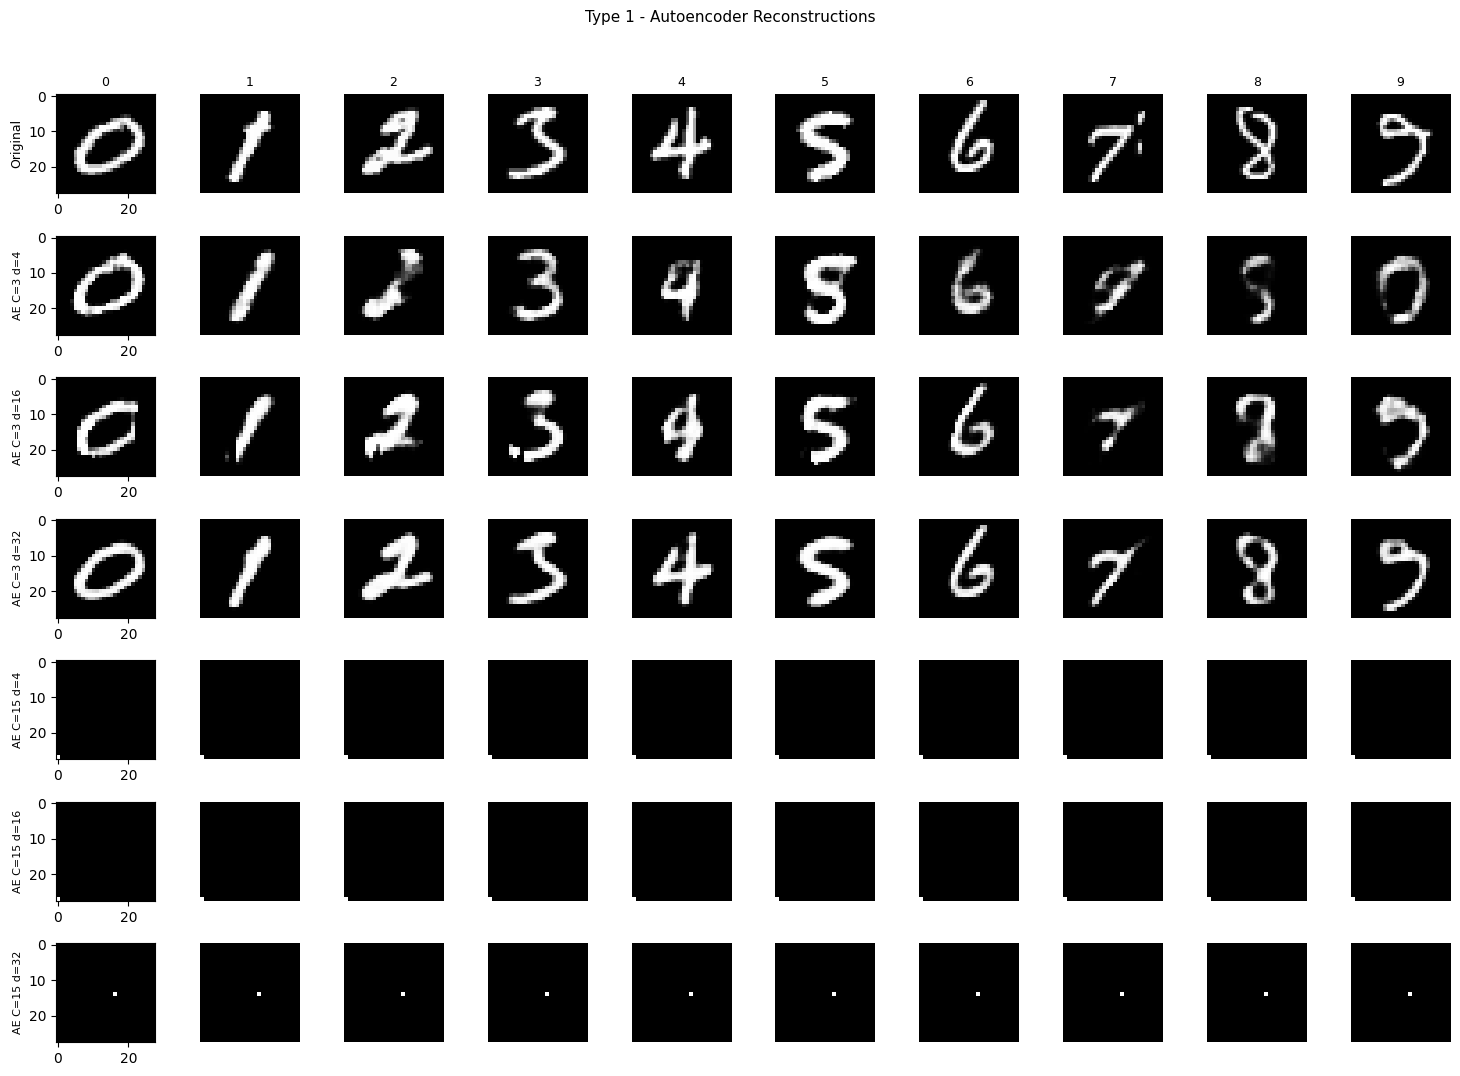

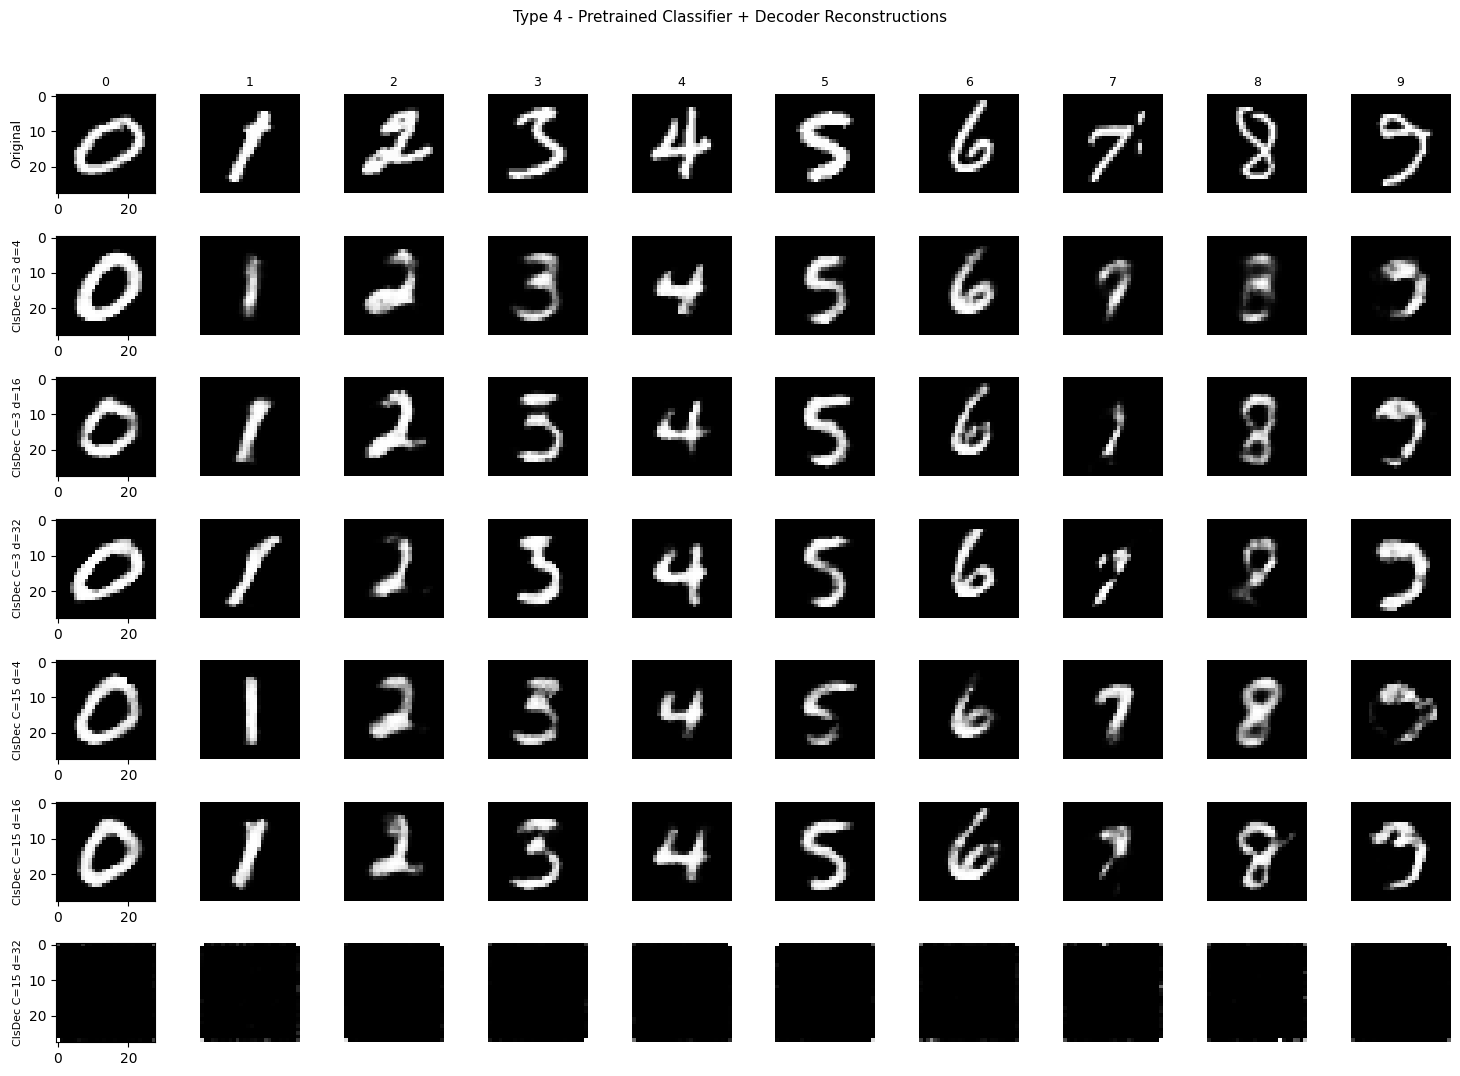

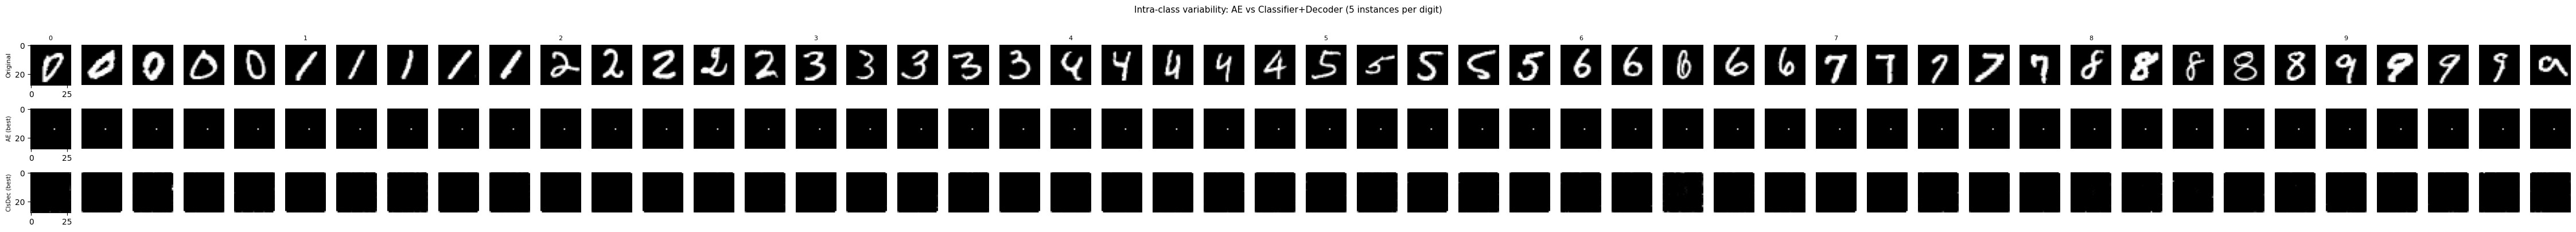

In [10]:
import matplotlib.pyplot as plt

def get_one_per_digit(loader):
    found = {}
    for images, labels in loader:
        for img, label in zip(images, labels):
            d = label.item()
            if d not in found:
                found[d] = img
            if len(found) == 10:
                break
        if len(found) == 10:
            break
    return torch.stack([found[d] for d in range(10)])  # ordered 0-9


def show_reconstructions(models_dict, images, title="Original vs. Reconstructed"):
    n = images.shape[0]
    rows = 1 + len(models_dict)
    fig, axes = plt.subplots(rows, n, figsize=(n * 1.5, rows * 1.5))
    fig.suptitle(title, fontsize=11, y=1.02)
    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title(str(i), fontsize=9)
    axes[0, 0].set_ylabel("Original", fontsize=9)
    axes[0, 0].axis("on")
    for row, (label, model) in enumerate(models_dict.items(), start=1):
        device = next(model.parameters()).device
        model.eval()
        with torch.no_grad():
            reconstructed = model(images.to(device)).cpu()
        for i in range(n):
            axes[row, i].imshow(reconstructed[i].squeeze(), cmap="gray")
            axes[row, i].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=8)
        axes[row, 0].axis("on")
    plt.tight_layout()
    plt.show()


def get_n_per_digit(loader, n=5):
    """Collect n instances of each digit (0-9). Returns (images, labels) tensors."""
    found = {d: [] for d in range(10)}
    for images, labels in loader:
        for img, label in zip(images, labels):
            d = label.item()
            if len(found[d]) < n:
                found[d].append(img)
        if all(len(v) == n for v in found.values()):
            break
    imgs = torch.stack([img for d in range(10) for img in found[d]])   # (10*n, 1, 28, 28)
    lbls = torch.tensor([d for d in range(10) for _ in range(n)])
    return imgs, lbls


def show_multiinstance_reconstructions(models_dict, images, n_per_digit=5,
                                        title="Multi-instance reconstruction"):
    """Shows n_per_digit columns per digit class, rows: original + one per model."""
    n_digits = 10
    total_cols = n_digits * n_per_digit
    rows = 1 + len(models_dict)
    fig, axes = plt.subplots(rows, total_cols,
                              figsize=(total_cols * 0.9, rows * 1.3))
    fig.suptitle(title, fontsize=11, y=1.02)

    for col in range(total_cols):
        axes[0, col].imshow(images[col].squeeze(), cmap="gray")
        axes[0, col].axis("off")
    for d in range(n_digits):
        axes[0, d * n_per_digit].set_title(str(d), fontsize=8)
    axes[0, 0].set_ylabel("Original", fontsize=8)
    axes[0, 0].axis("on")

    for row, (label, model) in enumerate(models_dict.items(), start=1):
        device = next(model.parameters()).device
        model.eval()
        with torch.no_grad():
            recon = model(images.to(device)).cpu()
        for col in range(total_cols):
            axes[row, col].imshow(recon[col].squeeze(), cmap="gray")
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=7)
        axes[row, 0].axis("on")

    plt.tight_layout()
    plt.show()


train_loader_vis = get_mnist(batch_size=256, train=True)
sample_train_images = get_one_per_digit(train_loader_vis)

# --- Single image per digit: Types 1 and 4 ---
show_reconstructions(
    {f"AE C={m.kwargs['hidden_channels']} d={m.kwargs['latent_dim']}": m for m in trained_ae_models},
    sample_train_images,
    title="Type 1 - Autoencoder Reconstructions",
)
show_reconstructions(
    {f"ClsDec C={m.kwargs['hidden_channels']} d={m.kwargs['latent_dim']}": m for m in trained_cls_dec_models},
    sample_train_images,
    title="Type 4 - Pretrained Classifier + Decoder Reconstructions",
)

# --- Multiple instances per digit: intra-class variability comparison ---
multi_images, _ = get_n_per_digit(train_loader_vis, n=5)

show_multiinstance_reconstructions(
    {"AE (best)": trained_ae_models[-1],
     "ClsDec (best)": trained_cls_dec_models[-1]},
    multi_images, n_per_digit=5,
    title="Intra-class variability: AE vs Classifier+Decoder (5 instances per digit)",
)


## Q4 — Task-Specific Encoding

We compare two encoder-decoder pipelines:

| | **Q1 Autoencoder** | **Q4 Classifier + Decoder** |
|---|---|---|
| Encoder trained for | Pixel reconstruction | Digit classification |
| Decoder input | d-dimensional latent code | 10-dimensional class logits |
| Decoder trained for | Reconstruction (end-to-end with encoder) | Reconstruction (decoder only, encoder frozen) |

### Which produces better reconstruction error, and why?

The **Q1 autoencoder produces lower reconstruction error**. Its encoder is trained end-to-end with the decoder explicitly to preserve all visual information. The Q2 encoder is trained to discard information: it must collapse all the visual variation within each digit class (different stroke styles, slight rotations, thickness differences) into a single consistent class prediction. That discarded intra-class variation cannot be recovered by the decoder.

### Qualitative differences in reconstructed images

**Q1 (AE):** Reconstructions preserve instance-specific visual details — the thickness of strokes, the tilt of a "1", the loop size of a "9". Different instances of the same digit look different in the reconstruction, reflecting genuine variation in the original writing styles.

**Q4 (ClsDec):** Reconstructions look like "average" or "prototype" digits. Since the classification encoder maps all instances of, say, the digit "3" to nearly identical logit vectors (dominated by the "3" class), the decoder receives the same 10-vector for every "3" and produces the same generic image. Reconstructions are smoother and more canonical but lose individual character.

### Intra-class (per-digit) variability

**Higher in Q1.** The AE encoder retains instance-specific features in the latent code. Multiple "4"s from the training set will encode differently (open-top vs closed-top, different slant) and reconstruct differently. In Q4, the encoder collapses all "4"s to a near-identical logit vector → the decoder output is nearly the same for every "4" → minimal intra-class variation in reconstructions.

### Inter-class (between-digit) separation

**Higher in Q4.** The classification encoder is explicitly trained to maximise the margin between classes — that is its entire objective. Its 10-dimensional output is organised purely by class identity: digit "1" and digit "7" produce very different logit vectors even if they look visually similar. The AE encoder organises latent space by visual similarity: "1" and "7" share long vertical strokes and end up nearby in latent space, so their reconstructions through a paired decoder remain visually similar. The Q4 decoder, conditioned on highly separated class logits, produces outputs that are clearly distinguishable between classes.
